<a href="https://colab.research.google.com/github/PrachiKumar298/CRISPR-gRNA-Efficinecy/blob/main/mlProject(BaseLines).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# gRNA Efficiency Prediction — DeepHF Dataset
**Dataset**: DeepHF (Wang et al. 2019) — WT · eSpCas9 · HF1, ~165k guides total

**Models**:
- **CNN** (main model) — sequence-only, 5-channel one-hot + Cas9 variant branch
- **LightGBM** — hand-crafted + pre-computed features, compared against CNN
- **XGBoost** — same features as LightGBM, compared against CNN

**Sequences**: 22-mer integer-encoded; guide = positions 1–20; N kept as 5th channel

In [ ]:
# =====================================================
# CELL 1 — Install, Clone, Imports
# =====================================================
!pip install lightgbm xgboost shap -q
!git clone https://github.com/izhangcd/DeepHF.git

import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from itertools import product as iproduct
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling1D, Concatenate, MaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print('All imports OK')
print('TF:', tf.__version__)
print('Files:', os.listdir('/content/DeepHF/data/'))


Cloning into 'DeepHF'...
remote: Enumerating objects: 98, done.
remote: Total 98 (delta 0), reused 0 (delta 0), pack-reused 98 (from 1)
Receiving objects: 100% (98/98), 96.82 MiB | 19.65 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Updating files: 100% (16/16), done.
All imports OK
TF: 2.19.0
Files: ['wt_seq_data_array.pkl', 'esp_seq_data_array.pkl', 'hf_seq_data_array.pkl']


In [ ]:
# =====================================================
# CELL 2 — Load Pickle Files
# =====================================================
def load_pkl(path):
    with open(path, 'rb') as f:
        try:
            return pickle.load(f, encoding='latin1')
        except TypeError:
            return pickle.load(f)

wt_data  = load_pkl('/content/DeepHF/data/wt_seq_data_array.pkl')
esp_data = load_pkl('/content/DeepHF/data/esp_seq_data_array.pkl')
hf_data  = load_pkl('/content/DeepHF/data/hf_seq_data_array.pkl')

# Confirmed structure:
#   [0] int32   (N, 22) -- integer-encoded 22-mer (1=A 2=T 3=C 4=G 5=N)
#   [1] float64 (N, 11) -- pre-computed thermodynamic features
#   [2] float64 (N,)    -- efficiency scores already in [0,1]
for name, raw in [('WT', wt_data), ('eSpCas9', esp_data), ('HF1', hf_data)]:
    print(f'{name}: seq{raw[0].shape}  feats{raw[1].shape}  scores{raw[2].shape}')


WT: seq(55604, 22)  feats(55604, 11)  scores(55604,)
eSpCas9: seq(58617, 22)  feats(58617, 11)  scores(58617,)
HF1: seq(56888, 22)  feats(56888, 11)  scores(56888,)


In [ ]:
# =====================================================
# CELL 3 — Parse Into DataFrame
# =====================================================
INT_TO_BASE = {1:'A', 2:'T', 3:'C', 4:'G', 5:'N'}

def extract_from_tuple(raw, variant_name):
    seq_enc   = raw[0]
    feats_pre = raw[1]
    scores    = raw[2]
    full_seqs  = [''.join(INT_TO_BASE[b] for b in row) for row in seq_enc]
    guide_seqs = [s[1:21] for s in full_seqs]
    df = pd.DataFrame({
        'gRNA':       guide_seqs,
        'efficiency': scores.astype(float),
        'cas9':       variant_name
    })
    print(f'{variant_name}: {len(df):,} guides | score [{scores.min():.3f}, {scores.max():.3f}] | e.g. {full_seqs[0]}')
    return df, feats_pre

df_wt,  feats_wt  = extract_from_tuple(wt_data,  'WT')
df_esp, feats_esp = extract_from_tuple(esp_data, 'eSpCas9')
df_hf,  feats_hf  = extract_from_tuple(hf_data,  'HF1')

data          = pd.concat([df_wt, df_esp, df_hf], ignore_index=True)
precomp_feats = np.vstack([feats_wt, feats_esp, feats_hf]).astype(np.float32)

print(f'\nCombined: {data.shape}')
print(f'Pre-computed features: {precomp_feats.shape}')


WT: 55,604 guides | score [0.018, 1.000] | e.g. ATTTTTTTTTGCGGTTTTGGGC
eSpCas9: 58,617 guides | score [0.007, 1.000] | e.g. ATTTTTTTTTGCGGTTTTGGGC
HF1: 56,888 guides | score [0.009, 1.000] | e.g. ATTTTTTTTTGCGGTTTTGGGC

Combined: (171109, 3)
Pre-computed features: (171109, 11)


In [ ]:
# =====================================================
# CELL 4 — Preprocessing
# =====================================================
cas9_map = {'WT': 0, 'eSpCas9': 1, 'HF1': 2}
inv_map  = {v: k for k, v in cas9_map.items()}
data['cas9_enc'] = data['cas9'].map(cas9_map)

print(f'Total rows: {len(data):,}')
print('\nVariant counts:')
print(data['cas9'].value_counts())
print('\nEfficiency stats per variant:')
print(data.groupby('cas9')['efficiency'].describe().round(4))


Total rows: 171,109

Variant counts:
cas9
eSpCas9    58617
HF1        56888
WT         55604
Name: count, dtype: int64

Efficiency stats per variant:
           count    mean     std     min     25%     50%     75%  max
cas9                                                                 
HF1      56888.0  0.4784  0.2065  0.0085  0.3355  0.5006  0.6356  1.0
WT       55604.0  0.7265  0.2176  0.0182  0.6088  0.8019  0.8961  1.0
eSpCas9  58617.0  0.3583  0.1875  0.0071  0.2055  0.3414  0.4961  1.0


In [ ]:
# =====================================================
# CELL 5 — CNN Input: 5-Channel One-Hot Sequences
# =====================================================
MAP = {
    'A': [1,0,0,0,0],
    'T': [0,1,0,0,0],
    'C': [0,0,1,0,0],
    'G': [0,0,0,1,0],
    'N': [0,0,0,0,1]
}

X_seq  = np.array([[MAP[b] for b in seq] for seq in data['gRNA']], dtype=np.float32)
X_cas9 = np.eye(3, dtype=np.float32)[data['cas9_enc'].values]

print(f'Sequence one-hot: {X_seq.shape}   (N, 20, 5)')
print(f'Cas9 one-hot:     {X_cas9.shape}  (N, 3)')
print(f'Sample: {data["gRNA"].iloc[0]}  =>  shape {X_seq[0].shape}')


Sequence one-hot: (171109, 20, 5)   (N, 20, 5)
Cas9 one-hot:     (171109, 3)  (N, 3)
Sample: TTTTTTTTTGCGGTTTTGGG  =>  shape (20, 5)


In [ ]:
# =====================================================
# CELL 6 — Tree Model Features (LightGBM & XGBoost)
# =====================================================
SEQ_LEN = 20
BASES   = ['A', 'T', 'C', 'G']
DINUCS  = [''.join(p) for p in iproduct('ATCG', repeat=2)]
TRINUCS = [''.join(p) for p in iproduct('ATCG', repeat=3)]

def feat_gc(seq):
    gc = (seq.count('G') + seq.count('C')) / SEQ_LEN
    zones = []
    for i in range(4):
        z = seq[i*5:(i+1)*5]
        zones.append((z.count('G') + z.count('C')) / 5)
    return [gc] + zones

def feat_onehot(seq):
    return [1 if b == base else 0 for base in seq for b in BASES]

def feat_kmer3(seq):
    return [seq.count(k) / (SEQ_LEN - 2) for k in TRINUCS]

def feat_dinuc(seq):
    c = {d: 0 for d in DINUCS}
    for i in range(SEQ_LEN - 1):
        dn = seq[i:i+2]
        if dn in c:
            c[dn] += 1
    return [c[d] / (SEQ_LEN - 1) for d in DINUCS]

def feat_structural(seq):
    runs = []
    for b in BASES:
        run = mx = 0
        for ch in seq:
            run = run + 1 if ch == b else 0
            mx = max(mx, run)
        runs.append(mx)
    comp = {'A':'T', 'T':'A', 'C':'G', 'G':'C'}
    rc  = ''.join(comp.get(b, 'N') for b in reversed(seq))
    pal = sum(1 for a, b in zip(seq, rc) if a == b) / SEQ_LEN
    return runs + [pal]

def build_tree_features(seq, cas9_enc):
    return (
        feat_gc(seq)
        + feat_onehot(seq)
        + feat_kmer3(seq)
        + feat_dinuc(seq)
        + feat_structural(seq)
        + [float(cas9_enc)]
    )

print('Building hand-crafted features...')
X_hc = np.array([
    build_tree_features(row.gRNA, row.cas9_enc)
    for row in data.itertuples()
], dtype=np.float32)

X_tree = np.hstack([X_hc, precomp_feats])
y      = data['efficiency'].values.astype(np.float32)

print(f'Tree feature matrix: {X_tree.shape}')
print(f'Target y:            {y.shape}')


Building hand-crafted features...
Tree feature matrix: (171109, 182)
Target y:            (171109,)


In [ ]:
# =====================================================
# CELL 7 — Train / Test Split
# =====================================================
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42,
    stratify=data['cas9_enc'].values
)

X_train,     X_test     = X_tree[train_idx], X_tree[test_idx]
y_train,     y_test     = y[train_idx],      y[test_idx]
X_train_seq, X_test_seq = X_seq[train_idx],  X_seq[test_idx]
X_train_cas, X_test_cas = X_cas9[train_idx], X_cas9[test_idx]
test_cas9 = data['cas9_enc'].values[test_idx]

print(f'Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')
print('Variant split in test:')
for enc, name in inv_map.items():
    print(f'  {name}: {(test_cas9 == enc).sum():,}')


Train: 136,887  Test: 34,222
Variant split in test:
  WT: 11,121
  eSpCas9: 11,723
  HF1: 11,378


In [ ]:
# =====================================================
# CELL 8 — Main Model: CNN (sequence only)
# =====================================================
def build_cnn():
    seq_in = Input(shape=(20, 5), name='seq')
    x = Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = BatchNormalization()(x)
    x = Conv1D(128, 5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)

    cas_in = Input(shape=(3,), name='cas9')
    c = Dense(16, activation='relu')(cas_in)

    merged = Concatenate()([x, c])
    merged = Dense(64, activation='relu')(merged)
    merged = Dropout(0.2)(merged)
    out    = Dense(1, activation='sigmoid')(merged)

    return Model(inputs=[seq_in, cas_in], outputs=out)

tf.random.set_seed(42)
cnn_model = build_cnn()
cnn_model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
cnn_model.summary()

history = cnn_model.fit(
    [X_train_seq, X_train_cas], y_train,
    validation_data=([X_test_seq, X_test_cas], y_test),
    epochs=60,
    batch_size=512,
    callbacks=[
        EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=1)
    ],
    verbose=1
)

cnn_preds = cnn_model.predict([X_test_seq, X_test_cas], verbose=0).flatten()
cnn_r2    = r2_score(y_test, cnn_preds)
cnn_sp, _ = spearmanr(y_test, cnn_preds)

print(f'\n===== CNN (Main Model) =====')
print(f'R2:       {cnn_r2:.4f}')
print(f'Spearman: {cnn_sp:.4f}')
print('\nPer-variant:')
for enc, name in inv_map.items():
    mask = test_cas9 == enc
    r2v   = r2_score(y_test[mask], cnn_preds[mask])
    spv,_ = spearmanr(y_test[mask], cnn_preds[mask])
    print(f'  {name:<10}  R2={r2v:.4f}  Spearman={spv:.4f}')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 20, 5)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 128)   │      2,048 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 128)   │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 20, 128)   │     82,048 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 64)    │     24,640 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cas9 (InputLayer)   │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         64 │ cas9[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 131,905 (515.25 KB)

 Trainable params: 131,265 (512.75 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 66s 230ms/step - loss: 0.0247 - mae: 0.1217 - val_loss: 0.3248 - val_mae: 0.5118 - learning_rate: 0.0010
Epoch 2/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 66s 245ms/step - loss: 0.0167 - mae: 0.0982 - val_loss: 0.0205 - val_mae: 0.1117 - learning_rate: 0.0010
Epoch 3/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 61s 226ms/step - loss: 0.0148 - mae: 0.0922 - val_loss: 0.0149 - val_mae: 0.0908 - learning_rate: 0.0010
Epoch 4/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 64s 238ms/step - loss: 0.0137 - mae: 0.0884 - val_loss: 0.0139 - val_mae: 0.0880 - learning_rate: 0.0010
Epoch 5/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - loss: 0.0128 - mae: 0.0853 - val_loss: 0.0123 - val_mae: 0.0830 - learning_rate: 0.0010
Epoch 6/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 83s 226ms/step - loss: 0.0121 - mae: 0.0830 - val_loss: 0.0122 - val_mae: 0.0818 - learning_rate: 0.0010
Epoch 7/60
268/268 ━━━━━━━━━━━━━━━━━━━━ 85s 237ms/step - loss: 0.0116 - mae: 0.0812 - val_loss: 0.0116 - val_mae: 0.0805 - learnin

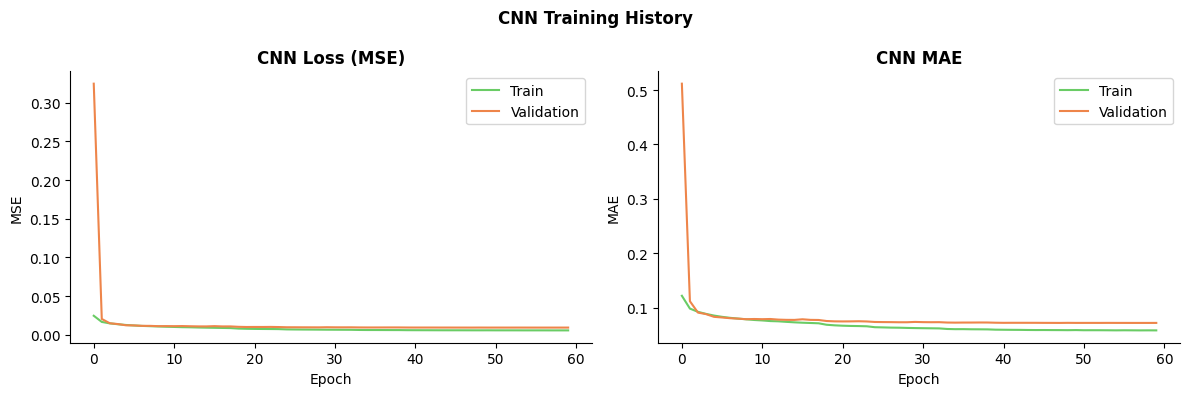

In [ ]:
# =====================================================
# CELL 9 — CNN Training Curve (MSE + MAE)
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train', color='#6acc65')
axes[0].plot(history.history['val_loss'], label='Validation', color='#ee854a')
axes[0].set_title('CNN Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(history.history['mae'],     label='Train', color='#6acc65')
axes[1].plot(history.history['val_mae'], label='Validation', color='#ee854a')
axes[1].set_title('CNN MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('CNN Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# =====================================================
# CELL 10 — Comparison Model 1: LightGBM
# =====================================================
lgb_eval_results = {}

lgb_model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.05,
    reg_lambda=0.3,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'valid'],
    eval_metric=['mse', 'mae'],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=200),
        lgb.record_evaluation(lgb_eval_results)
    ]
)

lgb_preds = lgb_model.predict(X_test)
lgb_r2    = r2_score(y_test, lgb_preds)
lgb_sp, _ = spearmanr(y_test, lgb_preds)

print(f'\n===== LightGBM (Comparison) =====')
print(f'R2:       {lgb_r2:.4f}')
print(f'Spearman: {lgb_sp:.4f}')
print('\nPer-variant:')
for enc, name in inv_map.items():
    mask = test_cas9 == enc
    r2v   = r2_score(y_test[mask], lgb_preds[mask])
    spv,_ = spearmanr(y_test[mask], lgb_preds[mask])
    print(f'  {name:<10}  R2={r2v:.4f}  Spearman={spv:.4f}')


[200]	train's l2: 0.0201479	train's l1: 0.113915	valid's l2: 0.0207546	valid's l1: 0.115512
[400]	train's l2: 0.0157058	train's l1: 0.0979997	valid's l2: 0.0166322	valid's l1: 0.1007
[600]	train's l2: 0.0137111	train's l1: 0.0909624	valid's l2: 0.0148771	valid's l1: 0.0945238
[800]	train's l2: 0.012552	train's l1: 0.0868909	valid's l2: 0.0139497	valid's l1: 0.0912951
[1000]	train's l2: 0.011736	train's l1: 0.0839761	valid's l2: 0.013336	valid's l1: 0.0891562
[1200]	train's l2: 0.0111306	train's l1: 0.0817588	valid's l2: 0.0129223	valid's l1: 0.087712
[1400]	train's l2: 0.0106451	train's l1: 0.0799403	valid's l2: 0.012607	valid's l1: 0.0866145
[1600]	train's l2: 0.0102358	train's l1: 0.0783633	valid's l2: 0.0123554	valid's l1: 0.0857207
[1800]	train's l2: 0.00986637	train's l1: 0.0769092	valid's l2: 0.0121319	valid's l1: 0.084923
[2000]	train's l2: 0.00953554	train's l1: 0.0755761	valid's l2: 0.0119441	valid's l1: 0.0842408

===== LightGBM (Comparison) =====
R2:       0.8159
Spearman: 0

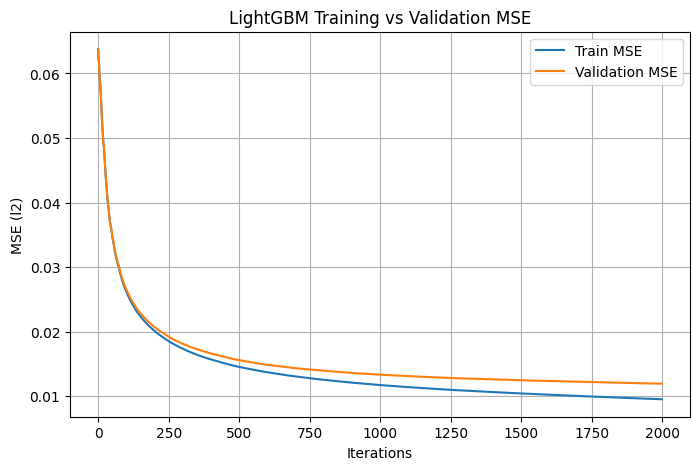

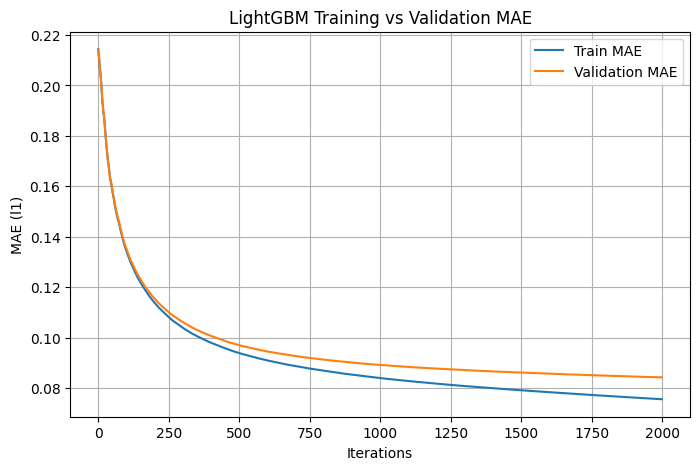

In [ ]:
import matplotlib.pyplot as plt

# =====================================================
# Extract metrics safely
# =====================================================
train_key = list(lgb_eval_results.keys())[0]
valid_key = list(lgb_eval_results.keys())[1]

# Metrics (LightGBM naming)
mse_key = 'l2'
mae_key = 'l1'

lgb_train_mse_hist = lgb_eval_results[train_key][mse_key]
lgb_val_mse_hist   = lgb_eval_results[valid_key][mse_key]

lgb_train_mae_hist = lgb_eval_results[train_key][mae_key]
lgb_val_mae_hist   = lgb_eval_results[valid_key][mae_key]

# =====================================================
# Plot MSE
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(lgb_train_mse_hist, label='Train MSE')
plt.plot(lgb_val_mse_hist, label='Validation MSE')
plt.xlabel('Iterations')
plt.ylabel('MSE (l2)')
plt.title('LightGBM Training vs Validation MSE')
plt.legend()
plt.grid()
plt.show()

# =====================================================
# Plot MAE
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(lgb_train_mae_hist, label='Train MAE')
plt.plot(lgb_val_mae_hist, label='Validation MAE')
plt.xlabel('Iterations')
plt.ylabel('MAE (l1)')
plt.title('LightGBM Training vs Validation MAE')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# =====================================================
# CELL 11 — Comparison Model 2: XGBoost
# =====================================================
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.05,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric=['rmse', 'mae']
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=200
)

xgb_results = xgb_model.evals_result()
xgb_preds = xgb_model.predict(X_test)
xgb_r2    = r2_score(y_test, xgb_preds)
xgb_sp, _ = spearmanr(y_test, xgb_preds)

print(f'\n===== XGBoost (Comparison) =====')
print(f'R2:       {xgb_r2:.4f}')
print(f'Spearman: {xgb_sp:.4f}')
print('\nPer-variant:')
for enc, name in inv_map.items():
    mask = test_cas9 == enc
    r2v   = r2_score(y_test[mask], xgb_preds[mask])
    spv,_ = spearmanr(y_test[mask], xgb_preds[mask])
    print(f'  {name:<10}  R2={r2v:.4f}  Spearman={spv:.4f}')


[0]	validation_0-rmse:0.25402	validation_0-mae:0.21565	validation_1-rmse:0.25378	validation_1-mae:0.21530
[200]	validation_0-rmse:0.13857	validation_0-mae:0.11103	validation_1-rmse:0.14201	validation_1-mae:0.11368
[400]	validation_0-rmse:0.12071	validation_0-mae:0.09417	validation_1-rmse:0.12657	validation_1-mae:0.09861
[600]	validation_0-rmse:0.11198	validation_0-mae:0.08680	validation_1-rmse:0.11974	validation_1-mae:0.09266
[800]	validation_0-rmse:0.10651	validation_0-mae:0.08239	validation_1-rmse:0.11583	validation_1-mae:0.08940
[1000]	validation_0-rmse:0.10249	validation_0-mae:0.07924	validation_1-rmse:0.11312	validation_1-mae:0.08725
[1200]	validation_0-rmse:0.09950	validation_0-mae:0.07689	validation_1-rmse:0.11123	validation_1-mae:0.08574
[1400]	validation_0-rmse:0.09742	validation_0-mae:0.07529	validation_1-rmse:0.11002	validation_1-mae:0.08480
[1600]	validation_0-rmse:0.09639	validation_0-mae:0.07449	validation_1-rmse:0.10942	validation_1-mae:0.08434
[1800]	validation_0-rmse:0

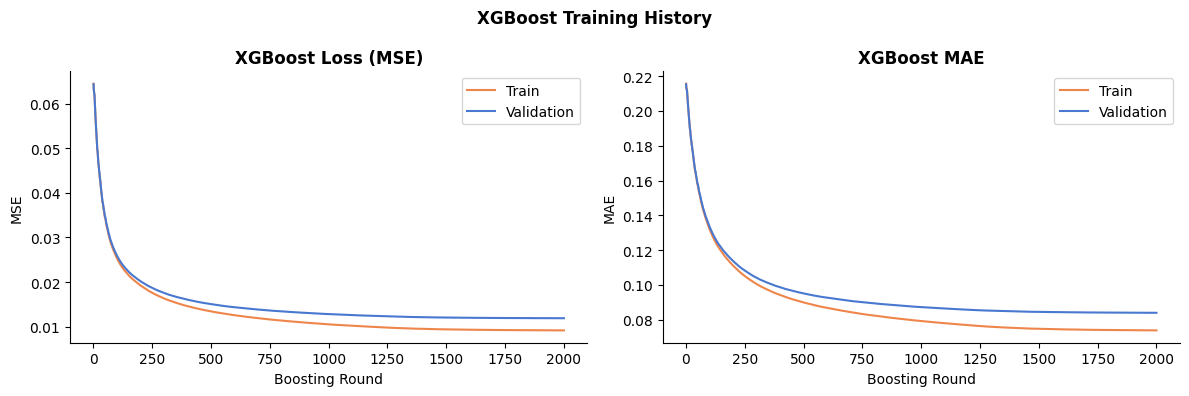

In [ ]:
# =====================================================
# CELL 11b — XGBoost Training Curves (MSE & MAE)
# =====================================================
# XGBoost eval set order: [0]=train, [1]=validation
xgb_train_rmse = xgb_results['validation_0']['rmse']
xgb_val_rmse   = xgb_results['validation_1']['rmse']
xgb_train_mae  = xgb_results['validation_0']['mae']
xgb_val_mae    = xgb_results['validation_1']['mae']

# Convert RMSE to MSE for consistency with CNN/LightGBM
xgb_train_mse_hist = [r**2 for r in xgb_train_rmse]
xgb_val_mse_hist   = [r**2 for r in xgb_val_rmse]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rounds_xgb = range(1, len(xgb_train_mse_hist) + 1)

axes[0].plot(rounds_xgb, xgb_train_mse_hist, label='Train',      color='#ee854a')
axes[0].plot(rounds_xgb, xgb_val_mse_hist,   label='Validation', color='#4878cf')
axes[0].set_title('XGBoost Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Boosting Round'); axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(rounds_xgb, xgb_train_mae, label='Train',      color='#ee854a')
axes[1].plot(rounds_xgb, xgb_val_mae,   label='Validation', color='#4878cf')
axes[1].set_title('XGBoost MAE', fontweight='bold')
axes[1].set_xlabel('Boosting Round'); axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('XGBoost Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()



Model              R2    Spearman   vs CNN R2   vs CNN Sp
-------------------------------------------------------
CNN            0.8557      0.9226     +0.0000     +0.0000 <- main
LightGBM       0.8159      0.9049     -0.0398     -0.0177
XGBoost        0.8170      0.9058     -0.0387     -0.0168


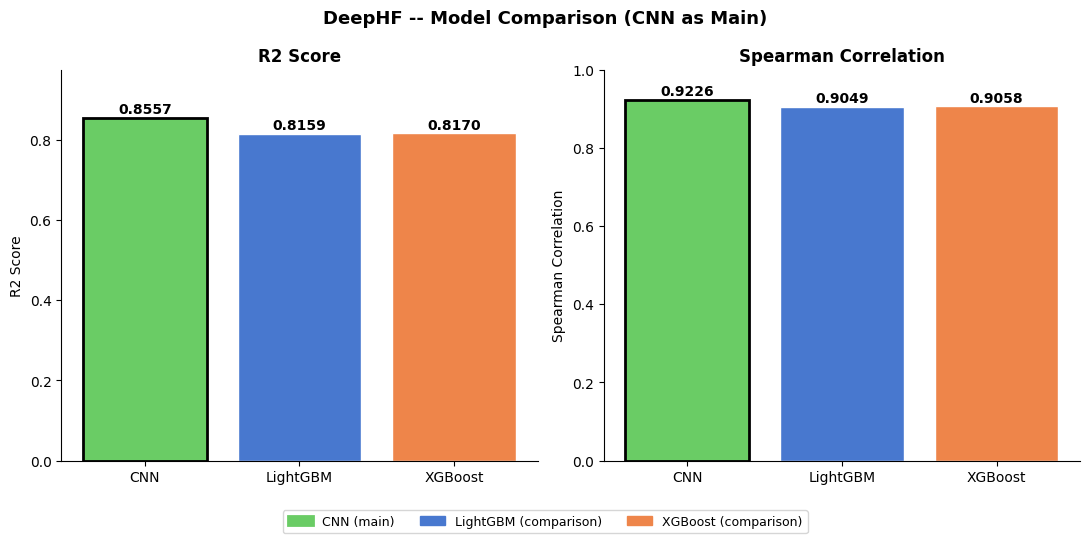

In [ ]:
# =====================================================
# CELL 12 — Overall Results Comparison
# =====================================================
results = {
    'CNN':      (cnn_r2, cnn_sp),
    'LightGBM': (lgb_r2, lgb_sp),
    'XGBoost':  (xgb_r2, xgb_sp),
}

print('\n' + '='*55)
print(f'{"Model":<12} {"R2":>8}  {"Spearman":>10}  {"vs CNN R2":>10}  {"vs CNN Sp":>10}')
print('-'*55)
for name, (r2v, spv) in results.items():
    dr2 = r2v - cnn_r2
    dsp = spv - cnn_sp
    marker = ' <- main' if name == 'CNN' else ''
    print(f'{name:<12} {r2v:>8.4f}  {spv:>10.4f}  {dr2:>+10.4f}  {dsp:>+10.4f}{marker}')
print('='*55)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = ['#6acc65', '#4878cf', '#ee854a']

for ax, metric_idx, title in zip(axes, [0, 1], ['R2 Score', 'Spearman Correlation']):
    vals  = [v[metric_idx] for v in results.values()]
    names = list(results.keys())
    bars  = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1)
    bars[0].set_edgecolor('black'); bars[0].set_linewidth(2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.003, f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(title)
    ax.set_ylim(0, min(1.0, max(vals) + 0.12))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#6acc65', label='CNN (main)', linewidth=2, edgecolor='black'),
    mpatches.Patch(color='#4878cf', label='LightGBM (comparison)'),
    mpatches.Patch(color='#ee854a', label='XGBoost (comparison)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('DeepHF -- Model Comparison (CNN as Main)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Model         WT R2     WT Sp       eSpCas9 R2eSpCas9 Sp  HF1 R2    HF1 Sp    
--------------------------------------------------------------------------------
CNN           0.8074    0.8754      0.7292    0.8617      0.7778    0.8703     <-
LightGBM      0.7430    0.8465      0.6868    0.8458      0.7016    0.8351    
XGBoost       0.7479    0.8479      0.6871    0.8476      0.7009    0.8366    


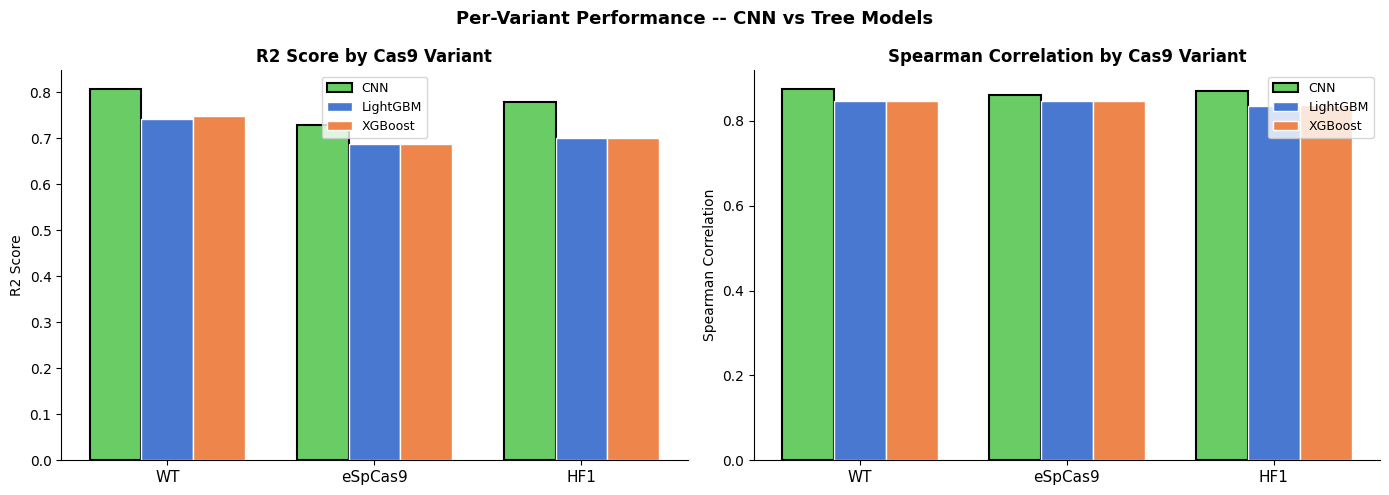

In [ ]:
# =====================================================
# CELL 13 — Per-Variant Comparison (all 3 models)
# =====================================================
pred_sets = {
    'CNN':      cnn_preds,
    'LightGBM': lgb_preds,
    'XGBoost':  xgb_preds,
}
variants = [inv_map[i] for i in range(3)]

print(f'{"Model":<12}', end='')
for v in variants:
    print(f'  {v+" R2":<10}{v+" Sp":<10}', end='')
print()
print('-' * 80)
for model_name, preds in pred_sets.items():
    marker = ' <-' if model_name == 'CNN' else ''
    print(f'{model_name:<12}', end='')
    for enc in range(3):
        mask = test_cas9 == enc
        r2v   = r2_score(y_test[mask], preds[mask])
        spv,_ = spearmanr(y_test[mask], preds[mask])
        print(f'  {r2v:<10.4f}{spv:<10.4f}', end='')
    print(marker)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(len(variants))
width = 0.25
model_colors = ['#6acc65', '#4878cf', '#ee854a']

for ax, metric_idx, title in zip(axes, [0, 1], ['R2 Score', 'Spearman Correlation']):
    for i, (model_name, preds) in enumerate(pred_sets.items()):
        vals = []
        for enc in range(3):
            mask = test_cas9 == enc
            if metric_idx == 0:
                vals.append(r2_score(y_test[mask], preds[mask]))
            else:
                vals.append(spearmanr(y_test[mask], preds[mask])[0])
        bars = ax.bar(x + i*width, vals, width, label=model_name,
                      color=model_colors[i], edgecolor='white')
        if model_name == 'CNN':
            for bar in bars:
                bar.set_edgecolor('black'); bar.set_linewidth(1.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels(variants, fontsize=11)
    ax.set_title(f'{title} by Cas9 Variant', fontweight='bold')
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Per-Variant Performance -- CNN vs Tree Models', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('per_variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


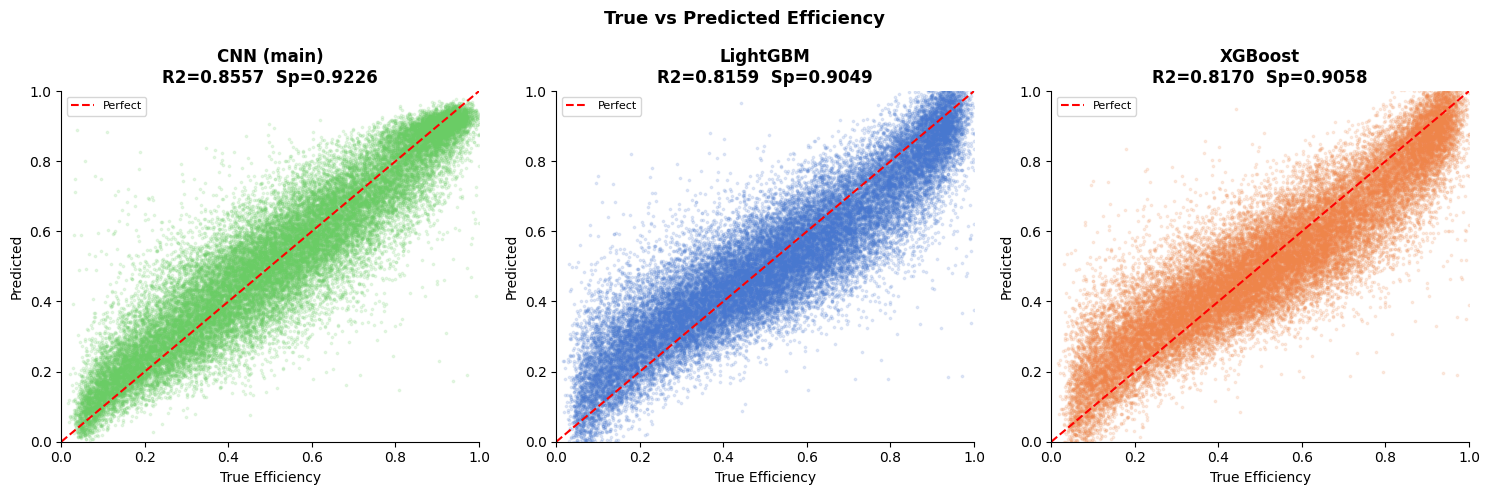

In [ ]:
# =====================================================
# CELL 14 — Scatter Plots: True vs Predicted
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_info = [
    ('CNN (main)',  cnn_preds, cnn_r2, cnn_sp,  '#6acc65'),
    ('LightGBM',   lgb_preds, lgb_r2, lgb_sp,  '#4878cf'),
    ('XGBoost',    xgb_preds, xgb_r2, xgb_sp,  '#ee854a'),
]
for ax, (name, preds, r2v, spv, color) in zip(axes, model_info):
    ax.scatter(y_test, preds, alpha=0.15, s=3, c=color)
    ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect')
    ax.set_title(f'{name}\nR2={r2v:.4f}  Sp={spv:.4f}', fontweight='bold')
    ax.set_xlabel('True Efficiency')
    ax.set_ylabel('Predicted')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('True vs Predicted Efficiency', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# =====================================================
# CELL 15 — Predict Efficiency for New gRNA
# =====================================================
def predict_cnn(sequence, cas9_variant='WT'):
    sequence = sequence.upper()[:20]
    enc      = cas9_map[cas9_variant]
    seq_enc  = np.array([[MAP.get(b, MAP['N']) for b in sequence]], dtype=np.float32)
    cas_enc  = np.eye(3, dtype=np.float32)[[enc]]
    return float(cnn_model.predict([seq_enc, cas_enc], verbose=0)[0, 0])

def predict_lgb(sequence, cas9_variant='WT'):
    sequence = sequence.upper()[:20]
    enc      = cas9_map[cas9_variant]
    feat     = np.array([build_tree_features(sequence, enc) + [0.0]*11], dtype=np.float32)
    return float(lgb_model.predict(feat)[0])

def predict_xgb(sequence, cas9_variant='WT'):
    sequence = sequence.upper()[:20]
    enc      = cas9_map[cas9_variant]
    feat     = np.array([build_tree_features(sequence, enc) + [0.0]*11], dtype=np.float32)
    return float(xgb_model.predict(feat)[0])

test_seq = 'ATGCTGCTGCTGCTGCTGCT'
print(f'gRNA: {test_seq}\n')
print(f'{"Variant":<12} {"CNN (main)":>12} {"LightGBM":>12} {"XGBoost":>12}')
print('-' * 52)
for v in ['WT', 'eSpCas9', 'HF1']:
    s_cnn = predict_cnn(test_seq, v)
    s_lgb = predict_lgb(test_seq, v)
    s_xgb = predict_xgb(test_seq, v)
    print(f'{v:<12} {s_cnn:>12.4f} {s_lgb:>12.4f} {s_xgb:>12.4f}')


gRNA: ATGCTGCTGCTGCTGCTGCT

Variant        CNN (main)     LightGBM      XGBoost
----------------------------------------------------
WT                 0.5587       0.7625       0.7686
eSpCas9            0.2142       0.4667       0.4402
HF1                0.3812       0.5091       0.4865


---
## A — Statistical Significance Testing

In [ ]:
# =====================================================
# CELL A1 — Bootstrap Confidence Intervals (2000 resamples)
# =====================================================
N_BOOT = 2000
rng    = np.random.default_rng(seed=42)

def bootstrap_metrics(y_true, y_pred, n_boot=N_BOOT):
    r2_b, sp_b = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        r2_b.append(r2_score(y_true[idx], y_pred[idx]))
        sp_b.append(spearmanr(y_true[idx], y_pred[idx])[0])
    return np.array(r2_b), np.array(sp_b)

def ci95(arr):
    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

print('Running bootstrap (2000 resamples x 3 models)...')
r2_cnn_b, sp_cnn_b = bootstrap_metrics(y_test, cnn_preds)
r2_lgb_b, sp_lgb_b = bootstrap_metrics(y_test, lgb_preds)
r2_xgb_b, sp_xgb_b = bootstrap_metrics(y_test, xgb_preds)
print('Done.')

print('\n===== Bootstrap 95% Confidence Intervals =====')
print(f'{"Model":<12} {"R2 Point":>10} {"R2 95% CI":>20}  {"Sp Point":>10} {"Sp 95% CI":>20}')
print('-' * 78)
for name, r2_pt, r2_b, sp_pt, sp_b in [
    ('CNN',      cnn_r2, r2_cnn_b, cnn_sp, sp_cnn_b),
    ('LightGBM', lgb_r2, r2_lgb_b, lgb_sp, sp_lgb_b),
    ('XGBoost',  xgb_r2, r2_xgb_b, xgb_sp, sp_xgb_b),
]:
    r2_lo, r2_hi = ci95(r2_b)
    sp_lo, sp_hi = ci95(sp_b)
    mark = ' <- main' if name == 'CNN' else ''
    print(f'{name:<12} {r2_pt:>10.4f} [{r2_lo:.4f}, {r2_hi:.4f}]  '
          f'{sp_pt:>10.4f} [{sp_lo:.4f}, {sp_hi:.4f}]{mark}')


Running bootstrap (2000 resamples x 3 models)...
Done.

===== Bootstrap 95% Confidence Intervals =====
Model          R2 Point            R2 95% CI    Sp Point            Sp 95% CI
------------------------------------------------------------------------------
CNN              0.8557 [0.8518, 0.8594]      0.9226 [0.9203, 0.9248] <- main
LightGBM         0.8159 [0.8118, 0.8198]      0.9049 [0.9023, 0.9075]
XGBoost          0.8170 [0.8133, 0.8210]      0.9058 [0.9033, 0.9083]


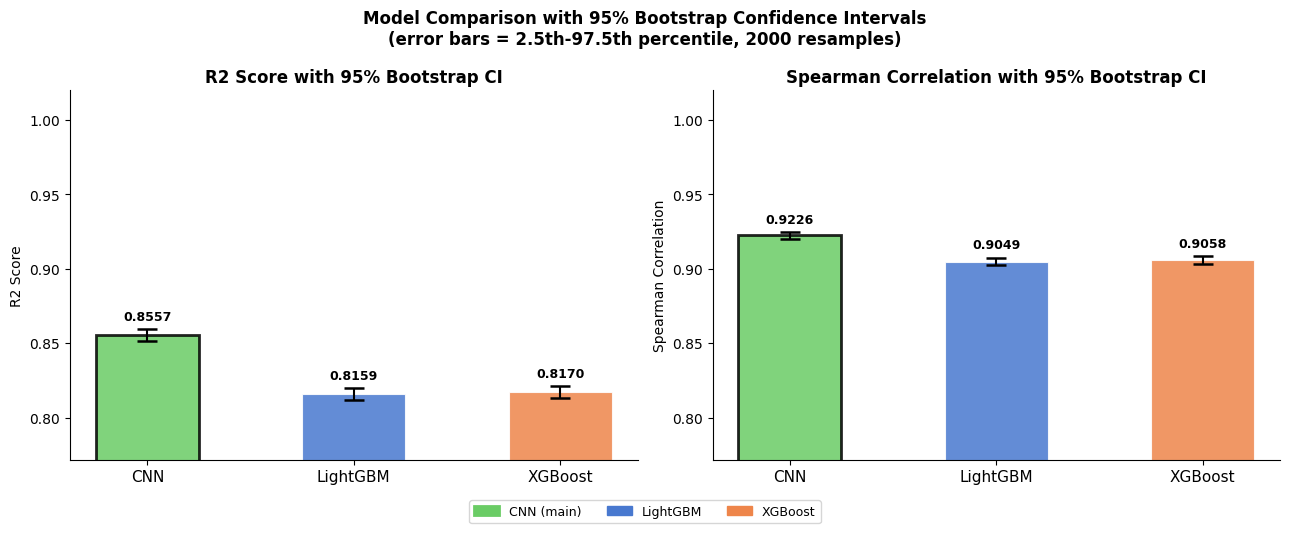

In [ ]:
# =====================================================
# CELL A2 — Bootstrap CI Bar Chart
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#6acc65', '#4878cf', '#ee854a']
names_plot = ['CNN', 'LightGBM', 'XGBoost']
x_pos  = np.arange(3)

boot_data = [
    (cnn_r2, r2_cnn_b, cnn_sp, sp_cnn_b),
    (lgb_r2, r2_lgb_b, lgb_sp, sp_lgb_b),
    (xgb_r2, r2_xgb_b, xgb_sp, sp_xgb_b),
]

for ax, metric_idx, title in zip(axes, [0, 1], ['R2 Score', 'Spearman Correlation']):
    for i, (r2_pt, r2_b, sp_pt, sp_b) in enumerate(boot_data):
        pt  = r2_pt  if metric_idx == 0 else sp_pt
        arr = r2_b   if metric_idx == 0 else sp_b
        lo, hi = ci95(arr)
        ax.bar(i, pt, color=colors[i], alpha=0.85,
               edgecolor='black' if names_plot[i] == 'CNN' else 'white',
               linewidth=2 if names_plot[i] == 'CNN' else 0.8, width=0.5)
        ax.errorbar(i, pt, yerr=[[pt - lo], [hi - pt]],
                    fmt='none', color='black', capsize=7, capthick=1.8, lw=1.5)
        ax.text(i, hi + 0.004, f'{pt:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names_plot, fontsize=11)
    ax.set_ylabel(title)
    ax.set_title(f'{title} with 95% Bootstrap CI', fontweight='bold')
    ymin = min(ci95(r2_cnn_b)[0], ci95(r2_lgb_b)[0], ci95(r2_xgb_b)[0])
    ax.set_ylim(max(0.0, ymin - 0.04), 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#6acc65', label='CNN (main)', edgecolor='black', linewidth=2),
    mpatches.Patch(color='#4878cf', label='LightGBM'),
    mpatches.Patch(color='#ee854a', label='XGBoost'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Model Comparison with 95% Bootstrap Confidence Intervals\n'
             '(error bars = 2.5th-97.5th percentile, 2000 resamples)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# =====================================================
# CELL A3 — Paired t-test + Wilcoxon on Squared Errors
# =====================================================
from scipy.stats import ttest_rel, wilcoxon

se_cnn = (y_test - cnn_preds) ** 2
se_lgb = (y_test - lgb_preds) ** 2
se_xgb = (y_test - xgb_preds) ** 2

def run_paired_tests(name_a, se_a, name_b, se_b):
    diff    = se_a - se_b
    t_stat, t_pval = ttest_rel(se_a, se_b)
    w_stat, w_pval = wilcoxon(se_a, se_b)
    better  = name_b if diff.mean() > 0 else name_a
    def sig(p):
        return '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else ('* p<0.05' if p < 0.05 else 'n.s.'))
    print(f'\n{name_a}  vs  {name_b}  (n={len(se_a):,} paired samples)')
    print(f'  Mean delta-MSE ({name_a} - {name_b}): {diff.mean():+.6f}  => {better} is better')
    print(f'  Paired t-test:        t = {t_stat:+7.2f},  p = {t_pval:.2e}  {sig(t_pval)}')
    print(f'  Wilcoxon signed-rank: W = {w_stat:10.0f}, p = {w_pval:.2e}  {sig(w_pval)}')

print('===== Paired Statistical Significance Tests =====')
print('H0: Both models have equal expected squared error')
print('Bonferroni-adjusted threshold for 3 comparisons: alpha = 0.001/3 = 0.00033')
run_paired_tests('CNN',      se_cnn, 'LightGBM', se_lgb)
run_paired_tests('CNN',      se_cnn, 'XGBoost',  se_xgb)
run_paired_tests('LightGBM', se_lgb, 'XGBoost',  se_xgb)


===== Paired Statistical Significance Tests =====
H0: Both models have equal expected squared error
Bonferroni-adjusted threshold for 3 comparisons: alpha = 0.001/3 = 0.00033

CNN  vs  LightGBM  (n=34,222 paired samples)
  Mean delta-MSE (CNN - LightGBM): -0.002581  => CNN is better
  Paired t-test:        t =  -23.98,  p = 4.45e-126  *** p<0.001
  Wilcoxon signed-rank: W =  231892441, p = 1.73e-243  *** p<0.001

CNN  vs  XGBoost  (n=34,222 paired samples)
  Mean delta-MSE (CNN - XGBoost): -0.002511  => CNN is better
  Paired t-test:        t =  -23.30,  p = 3.47e-119  *** p<0.001
  Wilcoxon signed-rank: W =  233123598, p = 7.91e-234  *** p<0.001

LightGBM  vs  XGBoost  (n=34,222 paired samples)
  Mean delta-MSE (LightGBM - XGBoost): +0.000070  => XGBoost is better
  Paired t-test:        t =   +3.57,  p = 3.61e-04  *** p<0.001
  Wilcoxon signed-rank: W =  288282604, p = 1.35e-02  * p<0.05


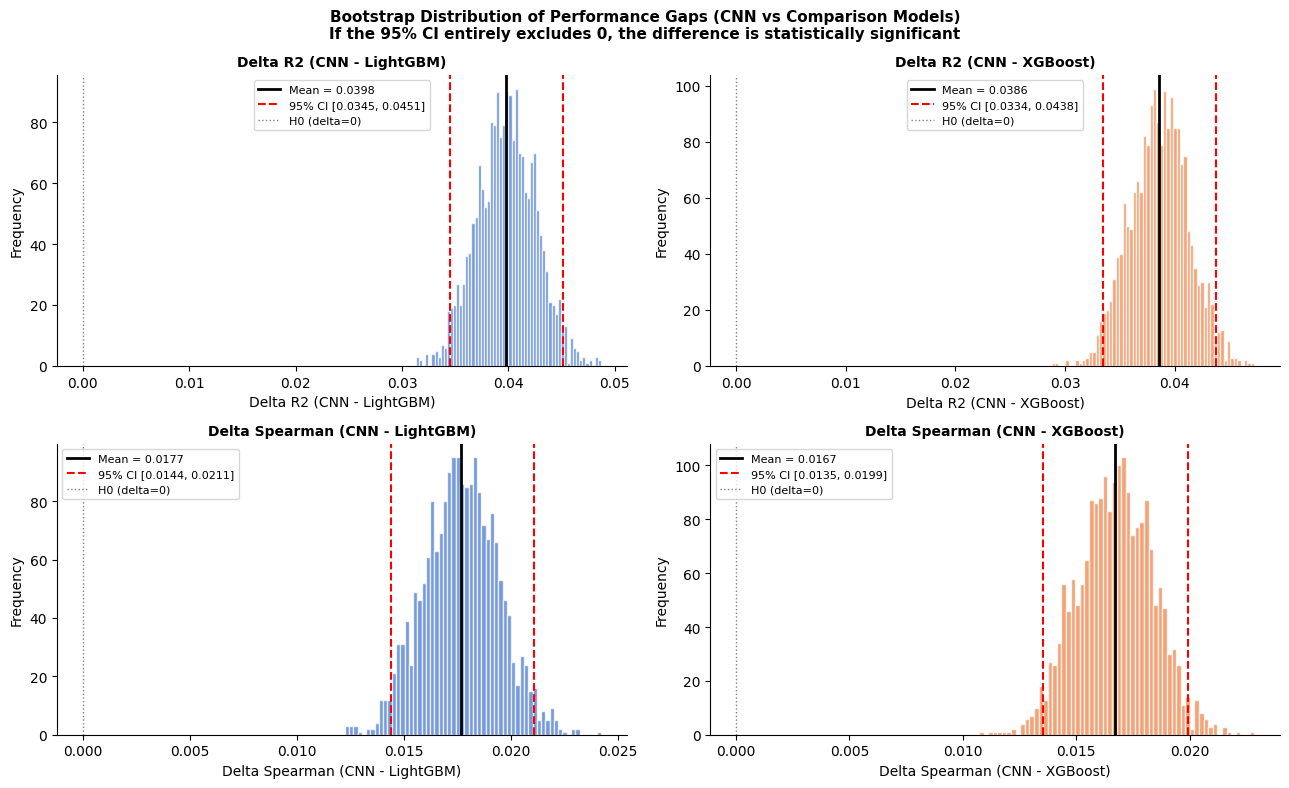


===== Delta-Metric Significance Summary =====
  Delta R2 (CNN - LightGBM)                    mean=+0.0398  CI=[+0.0345,+0.0451]  SIGNIFICANT (CI excludes 0)
  Delta R2 (CNN - XGBoost)                     mean=+0.0386  CI=[+0.0334,+0.0438]  SIGNIFICANT (CI excludes 0)
  Delta Spearman (CNN - LightGBM)              mean=+0.0177  CI=[+0.0144,+0.0211]  SIGNIFICANT (CI excludes 0)
  Delta Spearman (CNN - XGBoost)               mean=+0.0167  CI=[+0.0135,+0.0199]  SIGNIFICANT (CI excludes 0)


In [ ]:
# =====================================================
# CELL A4 — Bootstrap Delta-R2 Distribution
# =====================================================
delta_r2_cnn_lgb = r2_cnn_b - r2_lgb_b
delta_r2_cnn_xgb = r2_cnn_b - r2_xgb_b
delta_sp_cnn_lgb = sp_cnn_b - sp_lgb_b
delta_sp_cnn_xgb = sp_cnn_b - sp_xgb_b

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
deltas_plot = [
    (delta_r2_cnn_lgb, 'Delta R2 (CNN - LightGBM)', '#4878cf'),
    (delta_r2_cnn_xgb, 'Delta R2 (CNN - XGBoost)',  '#ee854a'),
    (delta_sp_cnn_lgb, 'Delta Spearman (CNN - LightGBM)', '#4878cf'),
    (delta_sp_cnn_xgb, 'Delta Spearman (CNN - XGBoost)',  '#ee854a'),
]

for ax, (arr, label, color) in zip(axes.flat, deltas_plot):
    lo, hi = ci95(arr)
    ax.hist(arr, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(arr.mean(), color='black', lw=2,   label=f'Mean = {arr.mean():.4f}')
    ax.axvline(lo, color='red', lw=1.5, ls='--',  label=f'95% CI [{lo:.4f}, {hi:.4f}]')
    ax.axvline(hi, color='red', lw=1.5, ls='--')
    ax.axvline(0,  color='gray', lw=1,  ls=':',   label='H0 (delta=0)')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Frequency')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bootstrap Distribution of Performance Gaps (CNN vs Comparison Models)\n'
             'If the 95% CI entirely excludes 0, the difference is statistically significant',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('bootstrap_delta_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n===== Delta-Metric Significance Summary =====')
for arr, label, _ in deltas_plot:
    lo, hi = ci95(arr)
    sig = 'SIGNIFICANT (CI excludes 0)' if lo > 0 or hi < 0 else 'not significant'
    print(f'  {label:<44} mean={arr.mean():+.4f}  CI=[{lo:+.4f},{hi:+.4f}]  {sig}')




---
## B — Feature Importance for Tree Models

In [ ]:
# =====================================================
# CELL B1 — Build Feature Name List + Gain Importance
# =====================================================
feat_names = (
    ['gc_global'] + [f'gc_zone{i}' for i in range(4)]
    + [f'pos{p}_{b}' for p in range(20) for b in BASES]
    + [f'3mer_{k}'   for k in TRINUCS]
    + [f'dinuc_{d}'  for d in DINUCS]
    + [f'maxrun_{b}' for b in BASES] + ['palindrome']
    + ['cas9_variant']
    + [f'thermo_{i}' for i in range(11)]
)  # 182 total

def get_group(name):
    if name.startswith('gc'):          return 'GC Content'
    if name.startswith('pos'):         return 'Positional One-Hot'
    if name.startswith('3mer'):        return 'Trinucleotide'
    if name.startswith('dinuc'):       return 'Dinucleotide'
    if name.startswith('maxrun') or name == 'palindrome': return 'Structural'
    if name == 'cas9_variant':         return 'Cas9 Variant'
    if name.startswith('thermo'):      return 'Thermodynamic'
    return 'Other'

lgb_imp      = lgb_model.feature_importances_
lgb_imp_norm = lgb_imp / lgb_imp.sum()
xgb_imp      = xgb_model.feature_importances_
xgb_imp_norm = xgb_imp / xgb_imp.sum()

TOP_K = 25
lgb_top_idx = np.argsort(lgb_imp_norm)[::-1][:TOP_K]
xgb_top_idx = np.argsort(xgb_imp_norm)[::-1][:TOP_K]

print(f'Top 10 LightGBM features (normalised gain):')
for i, idx in enumerate(lgb_top_idx[:10]):
    print(f'  {i+1:2d}. {feat_names[idx]:<25} {lgb_imp_norm[idx]:.4f}  [{get_group(feat_names[idx])}]')
print(f'\nTop 10 XGBoost features (normalised gain):')
for i, idx in enumerate(xgb_top_idx[:10]):
    print(f'  {i+1:2d}. {feat_names[idx]:<25} {xgb_imp_norm[idx]:.4f}  [{get_group(feat_names[idx])}]')


Top 10 LightGBM features (normalised gain):
   1. thermo_8                  0.0711  [Thermodynamic]
   2. thermo_1                  0.0504  [Thermodynamic]
   3. thermo_10                 0.0476  [Thermodynamic]
   4. thermo_9                  0.0415  [Thermodynamic]
   5. thermo_3                  0.0399  [Thermodynamic]
   6. thermo_7                  0.0337  [Thermodynamic]
   7. thermo_2                  0.0286  [Thermodynamic]
   8. cas9_variant              0.0282  [Cas9 Variant]
   9. gc_global                 0.0237  [GC Content]
  10. gc_zone3                  0.0218  [GC Content]

Top 10 XGBoost features (normalised gain):
   1. cas9_variant              0.1912  [Cas9 Variant]
   2. thermo_5                  0.0844  [Thermodynamic]
   3. pos19_G                   0.0420  [Positional One-Hot]
   4. pos19_C                   0.0396  [Positional One-Hot]
   5. thermo_6                  0.0345  [Thermodynamic]
   6. thermo_4                  0.0282  [Thermodynamic]
   7. pos19_T 

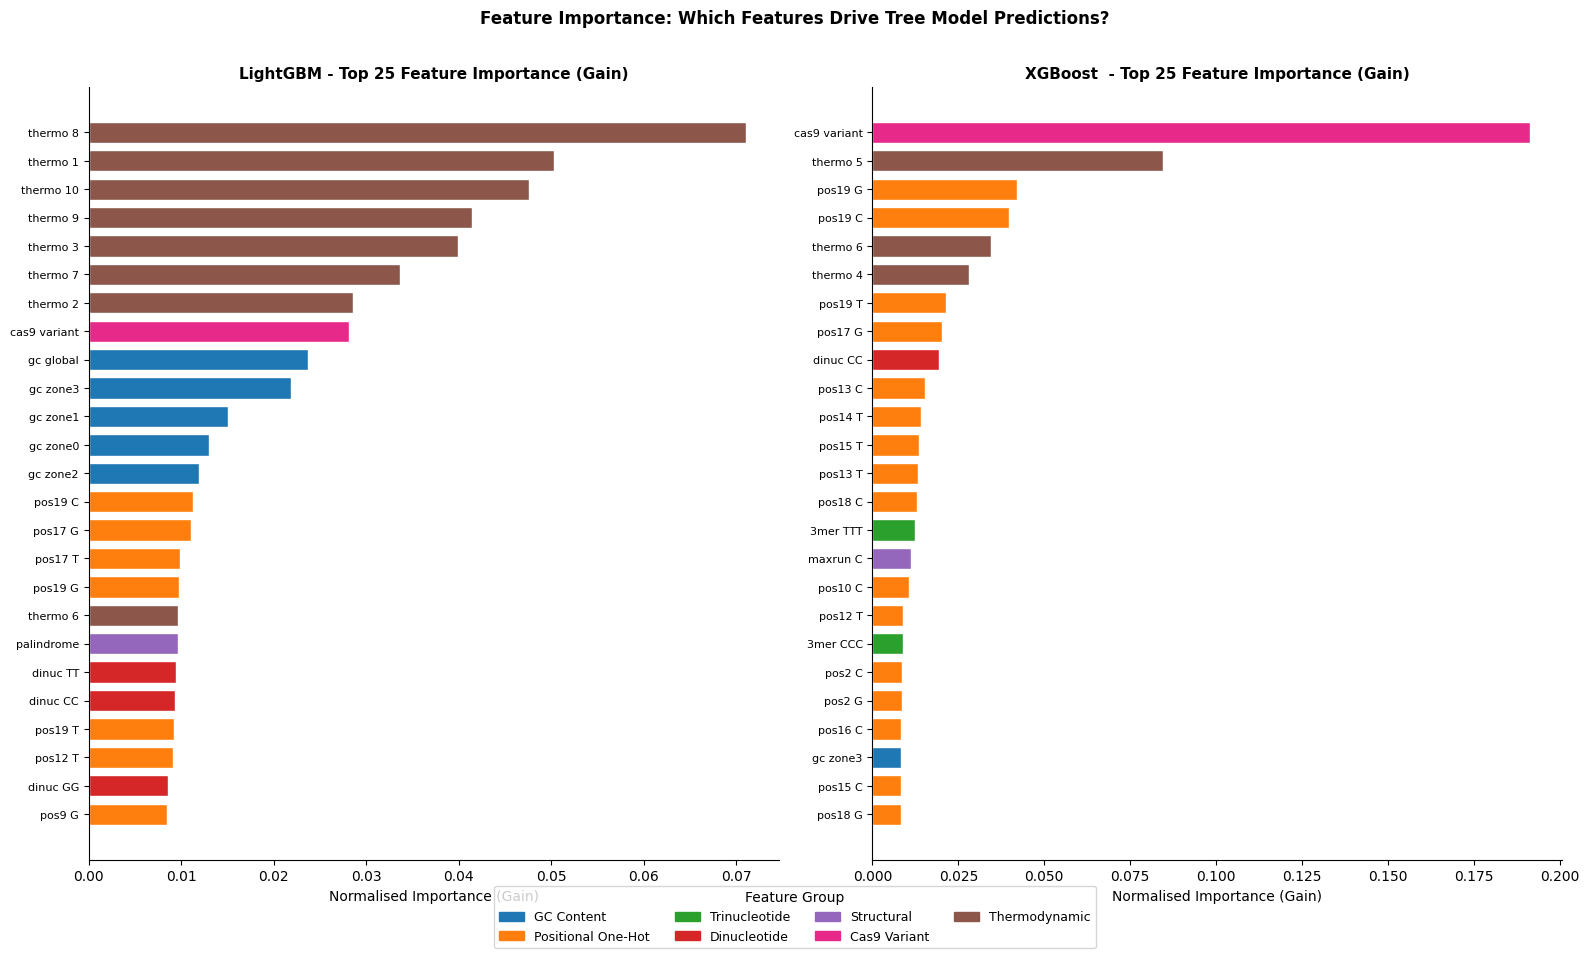

In [ ]:
# =====================================================
# CELL B2 — Top-25 Horizontal Bar Charts
# =====================================================
GROUP_COLORS = {
    'GC Content':        '#1F77B4',
    'Positional One-Hot':'#FF7F0E',
    'Trinucleotide':     '#2CA02C',
    'Dinucleotide':      '#D62728',
    'Structural':        '#9467BD',
    'Cas9 Variant':      '#E7298A',
    'Thermodynamic':     '#8C564B',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, imp_norm, top_idx, title in zip(
    axes,
    [lgb_imp_norm, xgb_imp_norm],
    [lgb_top_idx,  xgb_top_idx],
    ['LightGBM - Top 25 Feature Importance (Gain)',
     'XGBoost  - Top 25 Feature Importance (Gain)'],
):
    names_top  = [feat_names[i] for i in top_idx]
    vals_top   = [imp_norm[i]   for i in top_idx]
    colors_top = [GROUP_COLORS.get(get_group(n), '#7F7F7F') for n in names_top]
    ax.barh(range(TOP_K), vals_top[::-1],
            color=colors_top[::-1], edgecolor='white', height=0.75)
    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels([n.replace('_', ' ') for n in names_top[::-1]], fontsize=8)
    ax.set_xlabel('Normalised Importance (Gain)', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), title='Feature Group')
plt.suptitle('Feature Importance: Which Features Drive Tree Model Predictions?',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_top25.png', dpi=150, bbox_inches='tight')
plt.show()


===== Feature Group Importance =====
                    LightGBM  XGBoost
group                                
Cas9 Variant          0.0282   0.1912
Dinucleotide          0.0678   0.0406
GC Content            0.0854   0.0247
Positional One-Hot    0.3569   0.4498
Structural            0.0252   0.0226
Thermodynamic         0.3301   0.1830
Trinucleotide         0.1065   0.0880


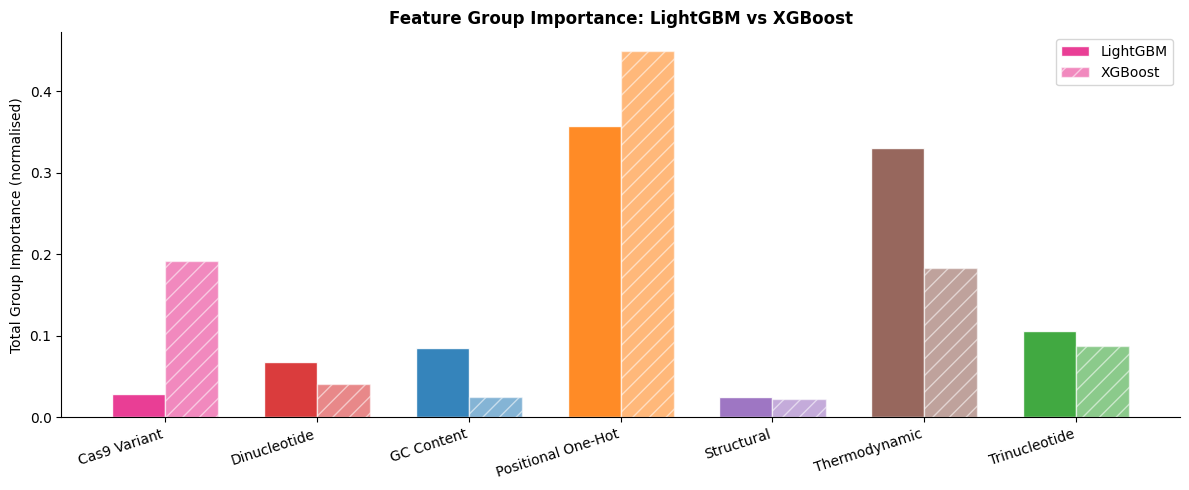

In [ ]:
# =====================================================
# CELL B3 — Feature Group Summary Bar Chart
# =====================================================
def group_importance(imp_norm):
    df = pd.DataFrame({'feature': feat_names, 'importance': imp_norm})
    df['group'] = df['feature'].apply(get_group)
    return df.groupby('group')['importance'].sum().sort_values(ascending=False)

lgb_grp = group_importance(lgb_imp_norm)
xgb_grp = group_importance(xgb_imp_norm)
combined = pd.DataFrame({'LightGBM': lgb_grp, 'XGBoost': xgb_grp}).fillna(0)

print('===== Feature Group Importance =====')
print(combined.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(12, 5))
groups   = combined.index.tolist()
x_g      = np.arange(len(groups))
w        = 0.35
colors_g = [GROUP_COLORS.get(g, '#7F7F7F') for g in groups]
ax.bar(x_g - w/2, combined['LightGBM'], w, label='LightGBM',
       color=colors_g, alpha=0.9, edgecolor='white')
ax.bar(x_g + w/2, combined['XGBoost'],  w, label='XGBoost',
       color=colors_g, alpha=0.55, edgecolor='white', hatch='//')
ax.set_xticks(x_g)
ax.set_xticklabels(groups, rotation=18, ha='right', fontsize=10)
ax.set_ylabel('Total Group Importance (normalised)', fontsize=10)
ax.set_title('Feature Group Importance: LightGBM vs XGBoost', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_group_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# =====================================================
# CELL B4 — SHAP Values: Simple Bar Plot for ALL 3 Models
# =====================================================
# Changed from beeswarm to simple mean(|SHAP|) bar charts.
# LightGBM: TreeExplainer
# XGBoost:  TreeExplainer
# CNN:      GradientExplainer (on 5-channel one-hot sequence input)
# =====================================================
import shap

SHAP_N = 3000
shap_idx = rng.integers(0, len(X_test), size=SHAP_N)
X_shap   = X_test[shap_idx]

# --- LightGBM SHAP (TreeExplainer) ---
print('Computing LightGBM SHAP values (TreeExplainer)...')
lgb_explainer   = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer.shap_values(X_shap)        # (SHAP_N, 182)
lgb_mean_shap   = np.abs(lgb_shap_values).mean(axis=0)     # (182,)

lgb_shap_top_idx   = np.argsort(lgb_mean_shap)[::-1][:20]
lgb_shap_top_names = [feat_names[i] for i in lgb_shap_top_idx]
lgb_shap_top_vals  = lgb_mean_shap[lgb_shap_top_idx]

# --- XGBoost SHAP (TreeExplainer) ---
print('Computing XGBoost SHAP values (TreeExplainer)...')
xgb_explainer   = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap)        # (SHAP_N, 182)
xgb_mean_shap   = np.abs(xgb_shap_values).mean(axis=0)     # (182,)

xgb_shap_top_idx   = np.argsort(xgb_mean_shap)[::-1][:20]
xgb_shap_top_names = [feat_names[i] for i in xgb_shap_top_idx]
xgb_shap_top_vals  = xgb_mean_shap[xgb_shap_top_idx]

# --- CNN SHAP (GradientExplainer) ---
# Uses 500 samples (smaller for speed); background = 100 training samples.
# SHAP computed over flattened 20x5 sequence input (100 features).
print('Computing CNN SHAP values (GradientExplainer, 500 samples)...')
SHAP_CNN_N = 500

cnn_shap_idx = rng.integers(0, len(X_test_seq), size=SHAP_CNN_N)
X_seq_shap   = X_test_seq[cnn_shap_idx].astype(np.float32)
X_cas9_shap  = X_test_cas[cnn_shap_idx].astype(np.float32)

bg_idx   = rng.integers(0, len(X_train_seq), size=100)
X_bg_seq = X_train_seq[bg_idx].astype(np.float32)
X_bg_cas = X_train_cas[bg_idx].astype(np.float32)

cnn_explainer = shap.GradientExplainer(
    cnn_model,
    [X_bg_seq, X_bg_cas]
)
cnn_shap_raw = cnn_explainer.shap_values(
    [X_seq_shap, X_cas9_shap]
)

# cnn_shap_raw[0]: (500, 20, 5)  -- sequence branch SHAP values
cnn_seq_shap  = cnn_shap_raw[0]                           # (500, 20, 5)
cnn_pos_shap  = np.abs(cnn_seq_shap).mean(axis=(0, 2))    # (20,) per position
cnn_base_shap = np.abs(cnn_seq_shap).mean(axis=0)         # (20, 5) per pos x base

# Flatten to (500, 100) for ranking
CHANNEL_NAMES    = ['A', 'T', 'C', 'G', 'N']
cnn_feat_names   = [f'pos{p+1}_{b}' for p in range(20) for b in CHANNEL_NAMES]
cnn_shap_flat    = np.abs(cnn_seq_shap).reshape(SHAP_CNN_N, -1)  # (500, 100)
cnn_mean_shap    = cnn_shap_flat.mean(axis=0)                     # (100,)

cnn_shap_top_idx   = np.argsort(cnn_mean_shap)[::-1][:20]
cnn_shap_top_names = [cnn_feat_names[i] for i in cnn_shap_top_idx]
cnn_shap_top_vals  = cnn_mean_shap[cnn_shap_top_idx]

print('SHAP computation complete.')


Computing LightGBM SHAP values (TreeExplainer)...
Computing XGBoost SHAP values (TreeExplainer)...
Computing CNN SHAP values (GradientExplainer, 500 samples)...
SHAP computation complete.


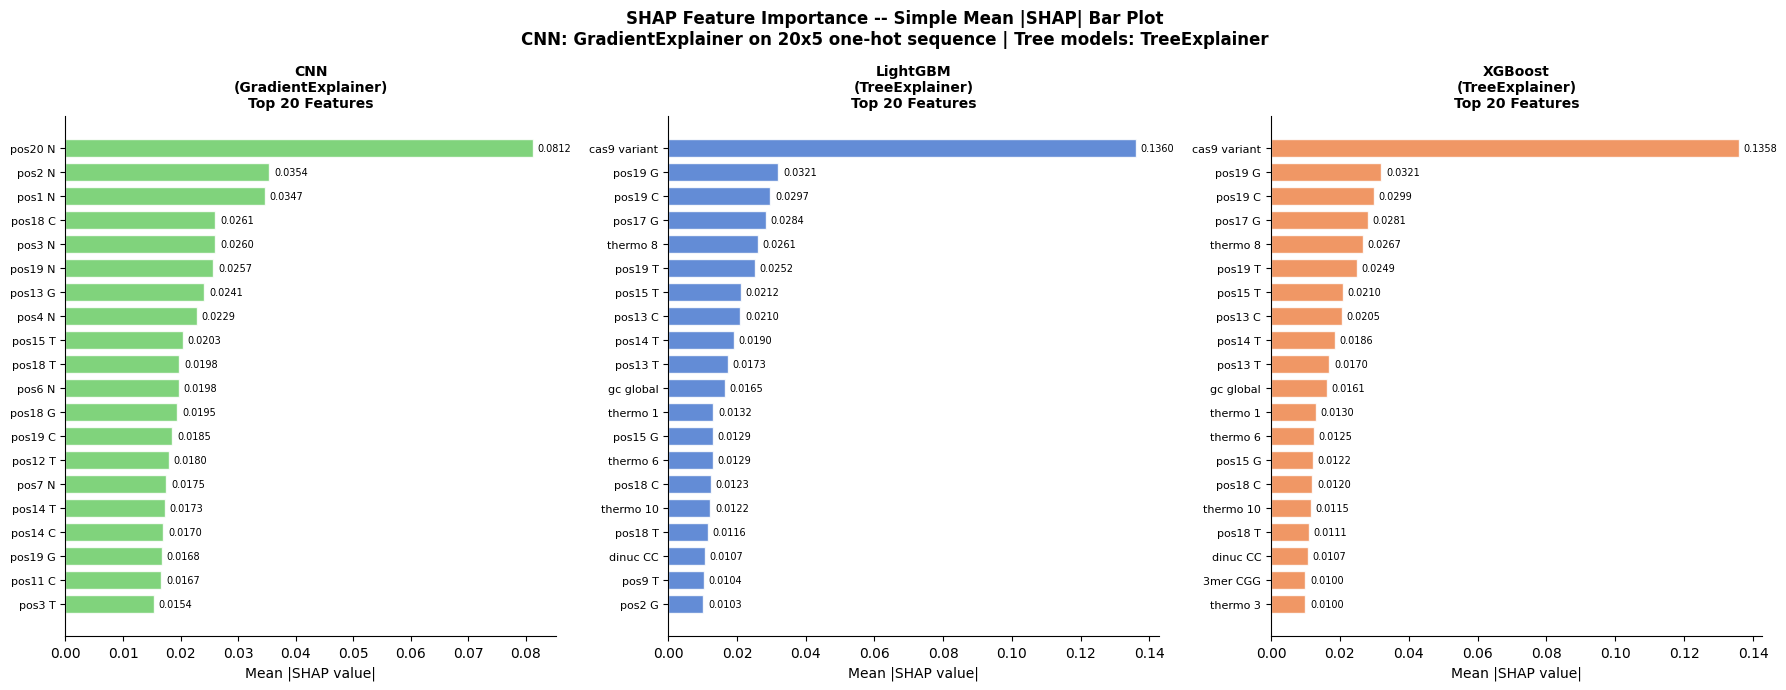

In [ ]:
# =====================================================
# CELL B5 — Simple SHAP Bar Charts for All 3 Models
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

shap_plot_data = [
    ('CNN\n(GradientExplainer)',     cnn_shap_top_names, cnn_shap_top_vals, '#6acc65'),
    ('LightGBM\n(TreeExplainer)',    lgb_shap_top_names, lgb_shap_top_vals, '#4878cf'),
    ('XGBoost\n(TreeExplainer)',     xgb_shap_top_names, xgb_shap_top_vals, '#ee854a'),
]

for ax, (title, names, vals, color) in zip(axes, shap_plot_data):
    y_pos = np.arange(len(names))
    ax.barh(y_pos, vals[::-1], color=color, alpha=0.85, edgecolor='white', height=0.75)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([n.replace('_', ' ') for n in names[::-1]], fontsize=8)
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.set_title(f'{title}\nTop 20 Features', fontweight='bold', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, v in enumerate(vals[::-1]):
        ax.text(v + max(vals)*0.01, i, f'{v:.4f}', va='center', fontsize=7)

plt.suptitle('SHAP Feature Importance -- Simple Mean |SHAP| Bar Plot\n'
             'CNN: GradientExplainer on 20x5 one-hot sequence | Tree models: TreeExplainer',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


** VAF -- Variance Accounted For (all 3 models)**

In [ ]:
# =====================================================
# CELL VAF1 — Overall VAF
# =====================================================
# VAF = 1 - Var(residuals) / Var(y_true)
# Directly interpretable as proportion of efficiency variance explained.
# Equivalent to R2 for zero-mean residuals; differs when residuals have bias.
# =====================================================
def vaf_score(y_true, y_pred):
    residuals = y_true - y_pred
    return 1.0 - np.var(residuals) / np.var(y_true)

cnn_vaf = vaf_score(y_test, cnn_preds)
lgb_vaf = vaf_score(y_test, lgb_preds)
xgb_vaf = vaf_score(y_test, xgb_preds)

print('\n===== Variance Accounted For (VAF) =====')
print(f'{"Model":<12} {"VAF":>8}  {"R2":>8}  {"Note"}')
print('-' * 45)
for name, vaf, r2v in [
    ('CNN',      cnn_vaf, cnn_r2),
    ('LightGBM', lgb_vaf, lgb_r2),
    ('XGBoost',  xgb_vaf, xgb_r2),
]:
    note = ' <- main' if name == 'CNN' else ''
    print(f'{name:<12} {vaf:>8.4f}  {r2v:>8.4f}{note}')

# Per-variant VAF
print('\n===== Per-Variant VAF =====')
print(f'{"Model":<12}', end='')
for enc in range(3):
    print(f'  {inv_map[enc]+" VAF":<14}', end='')
print()
print('-' * 60)

vaf_table = {}
for model_name, preds in pred_sets.items():
    vaf_table[model_name] = {}
    print(f'{model_name:<12}', end='')
    for enc in range(3):
        mask = test_cas9 == enc
        v = vaf_score(y_test[mask], preds[mask])
        vaf_table[model_name][inv_map[enc]] = v
        print(f'  {v:<14.4f}', end='')
    print()



===== Variance Accounted For (VAF) =====
Model             VAF        R2  Note
---------------------------------------------
CNN            0.8563    0.8557 <- main
LightGBM       0.8159    0.8159
XGBoost        0.8170    0.8170

===== Per-Variant VAF =====
Model         WT VAF          eSpCas9 VAF     HF1 VAF       
------------------------------------------------------------
CNN           0.8098          0.7296          0.7784        
LightGBM      0.7430          0.6868          0.7016        
XGBoost       0.7479          0.6871          0.7009        


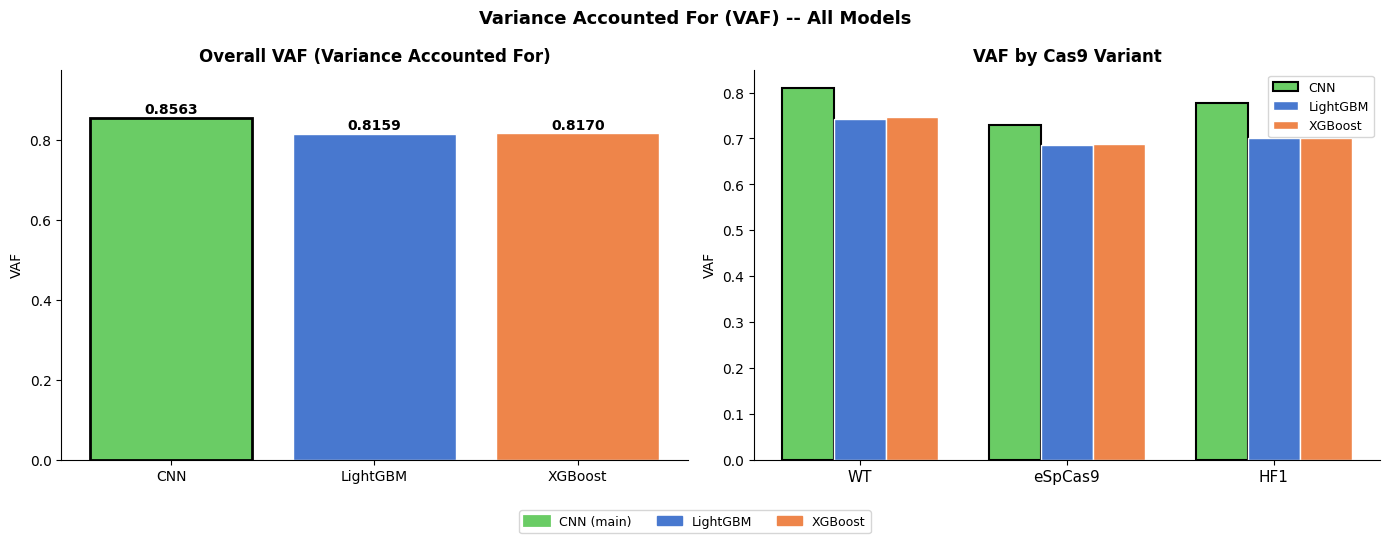

In [ ]:
# =====================================================
# CELL VAF2 — VAF Bar Charts: Overall + Per-Variant
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#6acc65', '#4878cf', '#ee854a']
model_names_plot = ['CNN', 'LightGBM', 'XGBoost']
vaf_overall = [cnn_vaf, lgb_vaf, xgb_vaf]

# Left: overall VAF
ax = axes[0]
bars = ax.bar(model_names_plot, vaf_overall, color=colors, edgecolor='white')
bars[0].set_edgecolor('black'); bars[0].set_linewidth(2)
for bar, val in zip(bars, vaf_overall):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Overall VAF (Variance Accounted For)', fontweight='bold', fontsize=12)
ax.set_ylabel('VAF')
ax.set_ylim(0, min(1.0, max(vaf_overall) + 0.12))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: per-variant VAF
ax2 = axes[1]
x   = np.arange(3)
w   = 0.25
variant_labels = [inv_map[i] for i in range(3)]
for i, (model_name, color) in enumerate(zip(model_names_plot, colors)):
    vals = [vaf_table[model_name][v] for v in variant_labels]
    bars2 = ax2.bar(x + i*w, vals, w, label=model_name, color=color, edgecolor='white')
    if model_name == 'CNN':
        for b in bars2:
            b.set_edgecolor('black'); b.set_linewidth(1.5)
ax2.set_xticks(x + w)
ax2.set_xticklabels(variant_labels, fontsize=11)
ax2.set_title('VAF by Cas9 Variant', fontweight='bold', fontsize=12)
ax2.set_ylabel('VAF')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

legend_patches2 = [
    mpatches.Patch(color='#6acc65', label='CNN (main)', edgecolor='black', linewidth=2),
    mpatches.Patch(color='#4878cf', label='LightGBM'),
    mpatches.Patch(color='#ee854a', label='XGBoost'),
]
fig.legend(handles=legend_patches2, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Variance Accounted For (VAF) -- All Models', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('vaf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


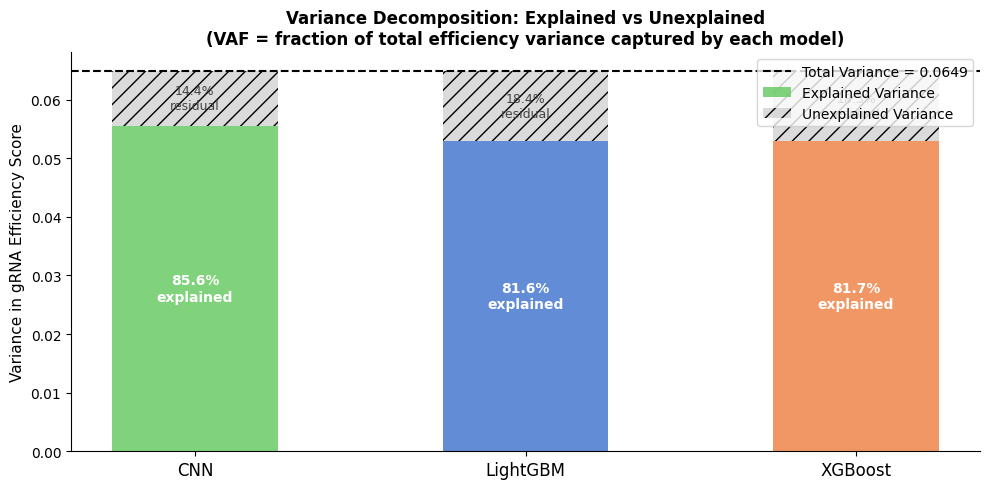

In [ ]:
# =====================================================
# CELL VAF3 — Variance Decomposition Plot
# =====================================================
# Stacked bar showing explained vs unexplained variance for each model.
# Total height = Var(y_true); bottom segment = explained variance.
# =====================================================
fig, ax = plt.subplots(figsize=(10, 5))

total_var  = np.var(y_test)
explained  = [total_var * v       for v in vaf_overall]
unexplained= [total_var * (1 - v) for v in vaf_overall]

x_pos = np.arange(3)
bar_w = 0.5

ax.bar(x_pos, explained,   bar_w, label='Explained Variance',   color=colors, alpha=0.85)
ax.bar(x_pos, unexplained, bar_w, bottom=explained,
       label='Unexplained Variance', color=['#cccccc']*3, alpha=0.7, hatch='//')

for i, (exp, unexp, vaf) in enumerate(zip(explained, unexplained, vaf_overall)):
    ax.text(i, exp / 2,       f'{vaf*100:.1f}%\nexplained',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(i, exp + unexp/2, f'{(1-vaf)*100:.1f}%\nresidual',
            ha='center', va='center', fontsize=9, color='#444444')

ax.axhline(total_var, color='black', ls='--', lw=1.5,
           label=f'Total Variance = {total_var:.4f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names_plot, fontsize=12)
ax.set_ylabel('Variance in gRNA Efficiency Score', fontsize=11)
ax.set_title('Variance Decomposition: Explained vs Unexplained\n'
             '(VAF = fraction of total efficiency variance captured by each model)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('vaf_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


**CNN Interpretability**

In [ ]:
# =====================================================
# CELL C1 — Position-Wise Sensitivity (Gradient x Input)
# =====================================================
import tensorflow as tf

GRAD_N = 2000
grad_idx      = rng.integers(0, len(X_test_seq), size=GRAD_N)
X_seq_sample  = tf.constant(X_test_seq[grad_idx], dtype=tf.float32)
X_cas9_sample = tf.constant(X_test_cas[grad_idx], dtype=tf.float32)

@tf.function
def get_gradients(seq_inp, cas9_inp):
    with tf.GradientTape() as tape:
        tape.watch(seq_inp)
        preds = cnn_model([seq_inp, cas9_inp], training=False)
    return tape.gradient(preds, seq_inp)

print('Computing input gradients...')
grads = get_gradients(X_seq_sample, X_cas9_sample).numpy()

grad_x_input     = grads * X_seq_sample.numpy()
sensitivity      = np.abs(grad_x_input).mean(axis=(0, 2))
sensitivity_norm = sensitivity / sensitivity.max()
per_base_sens    = np.abs(grad_x_input).mean(axis=0)

positions = np.arange(1, 21)
print('\nPosition-wise sensitivity (normalised):')
for i, s in enumerate(sensitivity_norm):
    bar = 'I' * int(s * 30)
    print(f'  Pos {i+1:2d}: {s:.3f}  {bar}')


Computing input gradients...

Position-wise sensitivity (normalised):
  Pos  1: 0.500  IIIIIIIIIIIIIII
  Pos  2: 0.654  IIIIIIIIIIIIIIIIIII
  Pos  3: 0.686  IIIIIIIIIIIIIIIIIIII
  Pos  4: 0.744  IIIIIIIIIIIIIIIIIIIIII
  Pos  5: 0.770  IIIIIIIIIIIIIIIIIIIIIII
  Pos  6: 0.697  IIIIIIIIIIIIIIIIIIII
  Pos  7: 0.668  IIIIIIIIIIIIIIIIIIII
  Pos  8: 0.638  IIIIIIIIIIIIIIIIIII
  Pos  9: 0.636  IIIIIIIIIIIIIIIIIII
  Pos 10: 0.825  IIIIIIIIIIIIIIIIIIIIIIII
  Pos 11: 0.871  IIIIIIIIIIIIIIIIIIIIIIIIII
  Pos 12: 0.739  IIIIIIIIIIIIIIIIIIIIII
  Pos 13: 0.793  IIIIIIIIIIIIIIIIIIIIIII
  Pos 14: 0.786  IIIIIIIIIIIIIIIIIIIIIII
  Pos 15: 0.802  IIIIIIIIIIIIIIIIIIIIIIII
  Pos 16: 0.931  IIIIIIIIIIIIIIIIIIIIIIIIIII
  Pos 17: 0.917  IIIIIIIIIIIIIIIIIIIIIIIIIII
  Pos 18: 1.000  IIIIIIIIIIIIIIIIIIIIIIIIIIIIII
  Pos 19: 0.854  IIIIIIIIIIIIIIIIIIIIIIIII
  Pos 20: 0.887  IIIIIIIIIIIIIIIIIIIIIIIIII


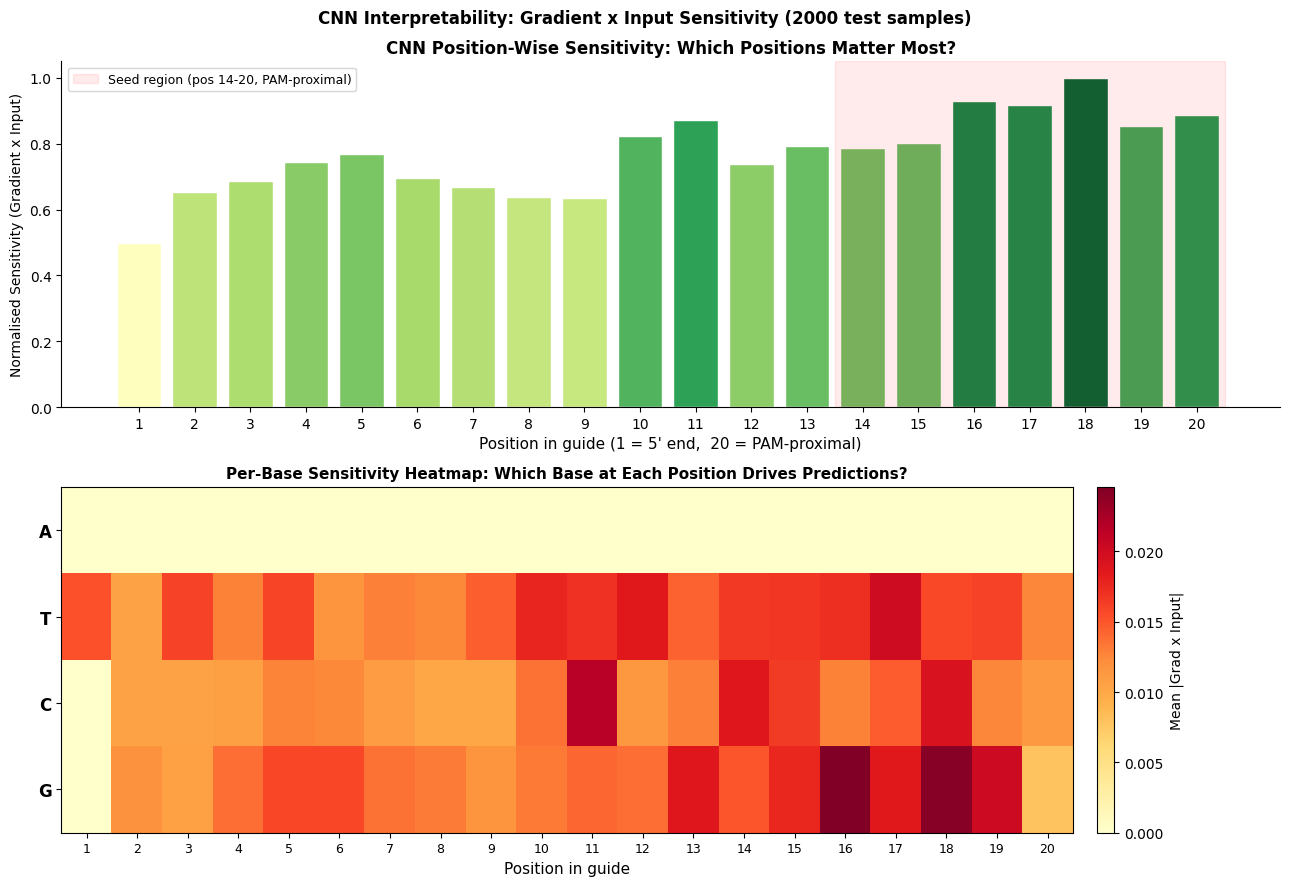

In [ ]:
# =====================================================
# CELL C2 — Sensitivity Bar + Heatmap
# =====================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
bar_colors = plt.cm.RdYlGn(sensitivity_norm)
ax.bar(positions, sensitivity_norm, color=bar_colors, edgecolor='white')
ax.axvspan(13.5, 20.5, alpha=0.08, color='red', label='Seed region (pos 14-20, PAM-proximal)')
ax.set_xlabel("Position in guide (1 = 5' end,  20 = PAM-proximal)", fontsize=11)
ax.set_ylabel('Normalised Sensitivity (Gradient x Input)', fontsize=10)
ax.set_title('CNN Position-Wise Sensitivity: Which Positions Matter Most?',
             fontweight='bold', fontsize=12)
ax.set_xticks(positions)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
hm  = ax2.imshow(per_base_sens[:, :4].T, aspect='auto', cmap='YlOrRd',
                  extent=[0.5, 20.5, -0.5, 3.5])
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(['G', 'C', 'T', 'A'], fontsize=12, fontweight='bold')
ax2.set_xticks(positions)
ax2.set_xticklabels(positions, fontsize=9)
ax2.set_xlabel('Position in guide', fontsize=11)
ax2.set_title('Per-Base Sensitivity Heatmap: Which Base at Each Position Drives Predictions?',
              fontweight='bold', fontsize=11)
plt.colorbar(hm, ax=ax2, label='Mean |Grad x Input|', pad=0.02)

plt.suptitle(f'CNN Interpretability: Gradient x Input Sensitivity ({GRAD_N} test samples)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# =====================================================
# CELL C3 — Occlusion Analysis
# =====================================================
OCC_N   = 1000
occ_idx = rng.integers(0, len(X_test_seq), size=OCC_N)
X_occ   = X_test_seq[occ_idx].copy()
cas_occ = X_test_cas[occ_idx]
N_ENC   = np.array([0, 0, 0, 0, 1], dtype=np.float32)

baseline = cnn_model.predict([X_occ, cas_occ], verbose=0).flatten()
occ_drop = np.zeros(20)

print('Running occlusion analysis (one position masked per run)...')
for pos in range(20):
    X_masked = X_occ.copy()
    X_masked[:, pos, :] = N_ENC
    occ_pred = cnn_model.predict([X_masked, cas_occ], verbose=0).flatten()
    occ_drop[pos] = (baseline - occ_pred).mean()
    print(f'  Pos {pos+1:2d}: mean drop = {occ_drop[pos]:+.5f}')
print('\nOcclusion analysis complete.')


Running occlusion analysis (one position masked per run)...
  Pos  1: mean drop = -0.01967
  Pos  2: mean drop = -0.03431
  Pos  3: mean drop = -0.03373
  Pos  4: mean drop = -0.03587
  Pos  5: mean drop = +0.01244
  Pos  6: mean drop = -0.03377
  Pos  7: mean drop = -0.01949
  Pos  8: mean drop = -0.02045
  Pos  9: mean drop = -0.00957
  Pos 10: mean drop = +0.01164
  Pos 11: mean drop = -0.01064
  Pos 12: mean drop = -0.00046
  Pos 13: mean drop = -0.00988
  Pos 14: mean drop = +0.04559
  Pos 15: mean drop = +0.02743
  Pos 16: mean drop = +0.03741
  Pos 17: mean drop = -0.01178
  Pos 18: mean drop = +0.00946
  Pos 19: mean drop = -0.03748
  Pos 20: mean drop = -0.08336

Occlusion analysis complete.


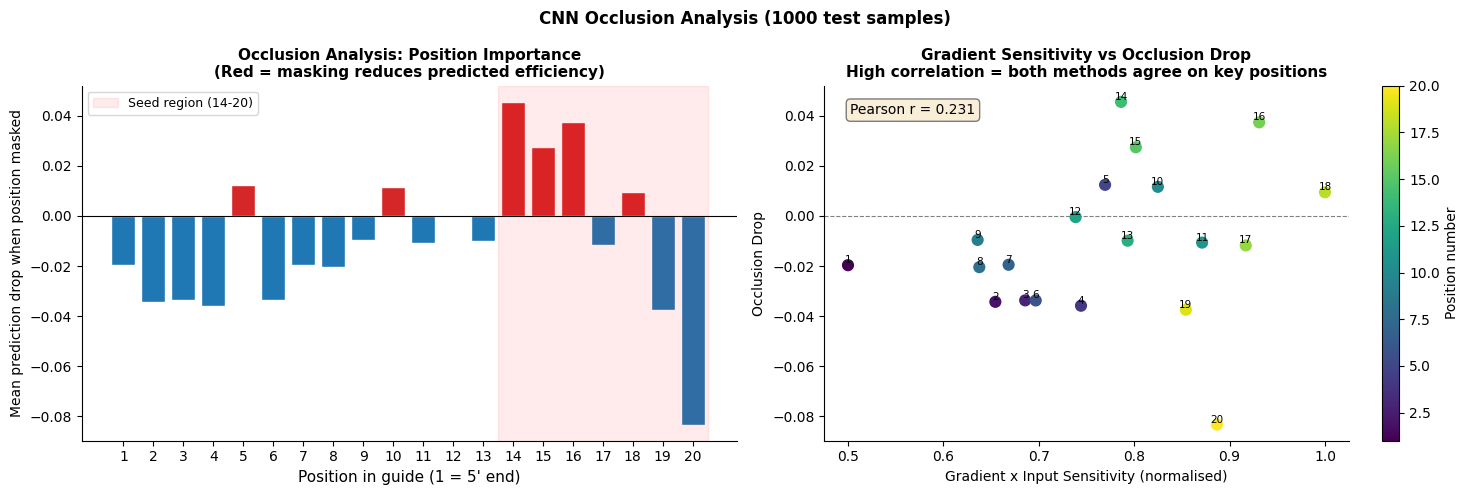

Pearson r (gradient vs occlusion): 0.231


In [ ]:
# =====================================================
# CELL C4 — Occlusion Drop Plot + Gradient vs Occlusion
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
bar_colors_occ = ['#d62728' if d > 0 else '#1f77b4' for d in occ_drop]
ax.bar(positions, occ_drop, color=bar_colors_occ, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(13.5, 20.5, alpha=0.08, color='red', label='Seed region (14-20)')
ax.set_xlabel("Position in guide (1 = 5' end)", fontsize=11)
ax.set_ylabel('Mean prediction drop when position masked', fontsize=10)
ax.set_title('Occlusion Analysis: Position Importance\n'
             '(Red = masking reduces predicted efficiency)',
             fontweight='bold', fontsize=11)
ax.set_xticks(positions)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
sc  = ax2.scatter(sensitivity_norm, occ_drop, c=positions, cmap='viridis', s=60, zorder=3)
for i, pos in enumerate(positions):
    ax2.annotate(str(pos), (sensitivity_norm[i], occ_drop[i]),
                 fontsize=7.5, ha='center', va='bottom')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
corr = np.corrcoef(sensitivity_norm, occ_drop)[0, 1]
ax2.text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=ax2.transAxes,
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax2.set_xlabel('Gradient x Input Sensitivity (normalised)', fontsize=10)
ax2.set_ylabel('Occlusion Drop', fontsize=10)
ax2.set_title('Gradient Sensitivity vs Occlusion Drop\n'
              'High correlation = both methods agree on key positions',
              fontweight='bold', fontsize=11)
plt.colorbar(sc, ax=ax2, label='Position number')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle(f'CNN Occlusion Analysis ({OCC_N} test samples)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_occlusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r (gradient vs occlusion): {corr:.3f}')


In [ ]:
# =====================================================
# CELL C6 — Complete Analysis Summary
# =====================================================
print('=' * 70)
print('COMPLETE ANALYSIS SUMMARY')
print('=' * 70)

print('\n--- A: Statistical Significance ---')
for arr, label, _ in deltas_plot:
    lo, hi = ci95(arr)
    sig = 'SIGNIFICANT' if lo > 0 or hi < 0 else 'not significant'
    print(f'  {label:<44} CI=[{lo:+.4f},{hi:+.4f}]  {sig}')

print('\n--- B: Top Feature Groups (LightGBM normalised gain) ---')
for grp, val in lgb_grp.items():
    print(f'  {grp:<22}: {val:.4f}  ({val*100:.1f}%)')

print('\n--- VAF Summary (with 95% Bootstrap CI) ---')
for name, vaf_pt, vaf_b, color in boot_vaf_data:
    lo, hi = ci95(vaf_b)
    print(f'  {name:<12} VAF={vaf_pt:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]')

print('\n--- C: CNN Most Sensitive Positions ---')
top5_grad = np.argsort(sensitivity_norm)[::-1][:5] + 1
top5_occ  = np.argsort(occ_drop)[::-1][:5] + 1
print(f'  Gradient sensitivity top-5 positions: {top5_grad.tolist()}')
print(f'  Occlusion drop      top-5 positions:  {top5_occ.tolist()}')
print(f'  Gradient vs Occlusion Pearson r:      {corr:.3f}')
print('=' * 70)


COMPLETE ANALYSIS SUMMARY

--- A: Statistical Significance ---
  Delta R2 (CNN - LightGBM)                    CI=[+0.0345,+0.0451]  SIGNIFICANT
  Delta R2 (CNN - XGBoost)                     CI=[+0.0334,+0.0438]  SIGNIFICANT
  Delta Spearman (CNN - LightGBM)              CI=[+0.0144,+0.0211]  SIGNIFICANT
  Delta Spearman (CNN - XGBoost)               CI=[+0.0135,+0.0199]  SIGNIFICANT

--- B: Top Feature Groups (LightGBM normalised gain) ---
  Positional One-Hot    : 0.3569  (35.7%)
  Thermodynamic         : 0.3301  (33.0%)
  Trinucleotide         : 0.1065  (10.6%)
  GC Content            : 0.0854  (8.5%)
  Dinucleotide          : 0.0678  (6.8%)
  Cas9 Variant          : 0.0282  (2.8%)
  Structural            : 0.0252  (2.5%)

--- VAF Summary (with 95% Bootstrap CI) ---
  CNN          VAF=0.8563  95% CI=[0.8527, 0.8600]
  LightGBM     VAF=0.8159  95% CI=[0.8121, 0.8197]
  XGBoost      VAF=0.8170  95% CI=[0.8132, 0.8207]

--- C: CNN Most Sensitive Positions ---
  Gradient sensitivity top